# Malatya Fault M7.2 Scenario

## 1. Setup

In [22]:
import os, json, shutil
from pathlib import Path
import xml.etree.ElementTree as ET
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import base64
from IPython.display import HTML

EVENT = 'malatya_fault_se'
os.environ['EVENT'] = EVENT

EVENT_DIR = Path.home() / 'shakemap_profiles/default/data' / EVENT / 'current'
PRODUCTS  = EVENT_DIR / 'products'
GF_OUT    = Path.home() / 'gf_output' / EVENT
TR_DATA   = Path.home() / 'turkey_inputs'

## 2. Malatya Fault Rupture

The Malatya Fault is a left-lateral strike-slip fault system in eastern Turkey, 
approximately 50 km northwest of Malatya city. It consists of three named segments 
in the AFAD 2026 Active Fault Database (FAYNO 265), with a combined length of ~175 km.

We use a M7.2 scenario rupture of the full fault system as a planning scenario 
for this region.

In [15]:
print("Malatya Fault — AFAD 2026 Active Fault Database")
print()
print(f"{'Segment':<20} {'Length':>8} {'Strike':>8} {'Dip':>6} {'Rake':>6}")
print("-" * 52)
print(f"{'Kemaliye':<20} {'65 km':>8} {'N15E':>8} {'90°':>6} {'-10°':>6}")
print(f"{'Arguvan':<20} {'37 km':>8} {'N25E':>8} {'90°':>6} {'-10°':>6}")
print(f"{'Akcadag':<20} {'73 km':>8} {'N25E':>8} {'90°':>6} {'-10°':>6}")
print("-" * 52)
print(f"{'Total':<20} {'175 km':>8}")
print()
print("Magnitude M7.2 | Seismogenic depth: 15 km")

Malatya Fault — AFAD 2026 Active Fault Database

Segment                Length   Strike    Dip   Rake
----------------------------------------------------
Kemaliye                65 km     N15E    90°   -10°
Arguvan                 37 km     N25E    90°   -10°
Akcadag                 73 km     N25E    90°   -10°
----------------------------------------------------
Total                  175 km

Magnitude M7.2 | Seismogenic depth: 15 km


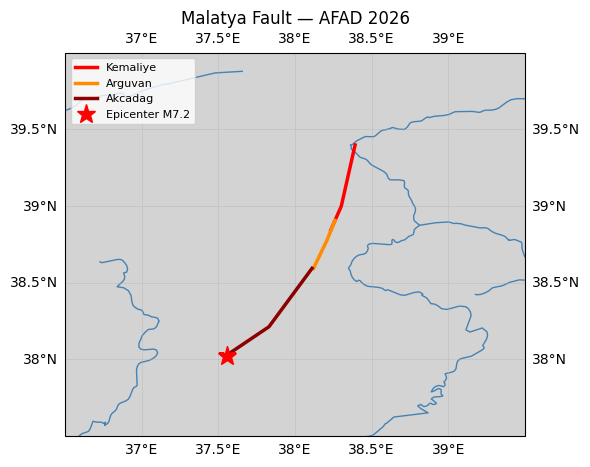

In [16]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Segment traces from AFAD shapefile
segments = {
    'Kemaliye': {'lons': [38.392, 38.302, 38.234], 'lats': [39.399, 39.000, 38.845], 'color': 'red'},
    'Arguvan':  {'lons': [38.261, 38.207, 38.120], 'lats': [38.907, 38.774, 38.593], 'color': 'darkorange'},
    'Akcadag':  {'lons': [38.111, 37.830, 37.545], 'lats': [38.594, 38.213, 38.021], 'color': 'darkred'},
}

fig, ax = plt.subplots(figsize=(6, 8), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([36.5, 39.5, 37.5, 40.0], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.RIVERS, edgecolor='steelblue')
ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)

for label, seg in segments.items():
    ax.plot(seg['lons'], seg['lats'], '-', color=seg['color'],
            linewidth=2.5, transform=ccrs.PlateCarree(), label=label)

ax.plot(37.555, 38.024, '*', color='red', markersize=14,
        transform=ccrs.PlateCarree(), label='Epicenter M7.2', zorder=10)

ax.legend(fontsize=8, loc='upper left')
ax.set_title('Malatya Fault — AFAD 2026')
plt.tight_layout()
plt.show()

### From fault trace to rupture.json

A ShakeMap `rupture.json` defines the fault plane as a closed polygon:

- **Top edge** — the surface trace coordinates at depth = 0 km
- **Bottom edge** — the same lon/lat coordinates at depth = 15 km (seismogenic depth)
- For a vertical fault (dip = 90°) the top and bottom edges are directly above each other

Each segment becomes one polygon in a `MultiPolygon` geometry.
For this scenario, the rupture was built from the AFAD shapefile trace (66 points per edge).

In [20]:
print("Key vertices from AFAD 2026 shapefile")
print()
print(f"{'Segment':<20} {'Lon':>10} {'Lat':>10}  Point")
print("-" * 58)
vertices = [
    ("Kemaliye", 38.392, 39.399, "N tip"),
    ("",                 38.302, 39.000, "mid"),
    ("",                 38.234, 38.845, "S tip"),
    ("Arguvan",  38.261, 38.907, "N tip"),
    ("",                 38.207, 38.774, "mid"),
    ("",                 38.120, 38.593, "S tip"),
    ("Akcadag",  38.111, 38.594, "N tip"),
    ("",                 37.830, 38.213, "mid"),
    ("",                 37.545, 38.021, "S tip"),
]
for seg, lon, lat, label in vertices:
    print(f"{seg:<20} {lon:>10.3f} {lat:>10.3f}  {label}")
print()
print("Each segment repeated at depth=15 km forms the bottom edge of the fault plane.")

Key vertices from AFAD 2026 shapefile

Segment                     Lon        Lat  Point
----------------------------------------------------------
Kemaliye                 38.392     39.399  N tip
                         38.302     39.000  mid
                         38.234     38.845  S tip
Arguvan                  38.261     38.907  N tip
                         38.207     38.774  mid
                         38.120     38.593  S tip
Akcadag                  38.111     38.594  N tip
                         37.830     38.213  mid
                         37.545     38.021  S tip

Each segment repeated at depth=15 km forms the bottom edge of the fault plane.


## 2. Run ShakeMap

**Magnitude M7.2** is a rough estimate from the fault length using the
Wells & Coppersmith (1994) scaling relationship for strike-slip faults.

The same ShakeMap pipeline as the morning demo:
- **`assemble`** — collect inputs (event origin + fault geometry + site conditions)
- **`model`** — compute ground motion using GMMs + Vs30 (expect ~2 min for this extent)
- **`contour`**, **`mapping`**, **`gridxml`** — outputs for visualization and ground failure

In [24]:
if not (EVENT_DIR / 'event.xml').exists():
    import subprocess, shutil
    subprocess.run(['sm_create', '-e', 'malatya_fault',
                    '2026-09-02T08:30:00', '37.555', '38.024',
                    '10.0', '7.2', 'Malatya Fault M7.2 Scenario',
                    'malatya_fault'], capture_output=True)
    repo = Path('/workspaces/shakemap-gf-workshop/data/event_configs/malatya_fault_se')
    shutil.copy(repo / 'rupture.json', EVENT_DIR / 'rupture.json')
    print('Event staged')

In [25]:
%%bash
shake $EVENT assemble -c 'demo' model contour mapping gridxml

INFO -- 2026-08-21 17:20:29 -- shake.main -- Running command assemble
INFO -- 2026-08-21 17:20:29 -- shake.main -- Finished running command assemble: Elapsed 0.14 secs
INFO -- 2026-08-21 17:20:29 -- shake.main -- Running command model
INFO -- 2026-08-21 17:20:29 -- model._threading_context -- BLAS thread limit: native/unrestricted (not set by ShakeMap)
INFO -- 2026-08-21 17:20:29 -- model._threading_context -- OpenMP thread limit: native/unrestricted (not set by ShakeMap)
INFO -- 2026-08-21 17:20:29 -- output_grid._adjust_resolution -- Resolution units specified in km, converting to degrees.
INFO -- 2026-08-21 17:20:29 -- output_grid._adjust_resolution -- Updated dx: 0.011518 (degrees)
INFO -- 2026-08-21 17:20:29 -- output_grid._adjust_resolution -- Updated dy: 0.0089932 (degrees)
WARNING -- 2026-08-21 17:20:55 -- warnings._showwarnmsg -- /opt/conda/envs/shakemap/lib/python3.12/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com

## 3. ShakeMap maps

Because we provided a finite fault geometry, shaking is elongated along the
N15°E fault strike rather than the circular pattern of a point source.
Compare the shaking footprint to the M7.6 San Andreas map from this morning —
note how local geology (Vs30) modifies the pattern.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, name, title in [
    (axes[0], 'intensity.jpg', 'MMI Intensity'),
    (axes[1], 'pga.jpg',       'PGA (%g)'),
]:
    img_path = PRODUCTS / name
    if img_path.exists():
        ax.imshow(mpimg.imread(img_path))
    ax.set_title(title, fontsize=13); ax.axis('off')
plt.suptitle('Malatya Fault M7.2', fontsize=14)
plt.tight_layout(); plt.show()

# save for comparison with Vs30 exercise
shutil.copy(PRODUCTS / 'intensity.jpg',
            Path.home() / 'malatya_global_vs30_intensity.jpg')

**Discussion:**
- Which cities appear to experience the highest shaking?
- How does the shaking pattern compare to the San Andreas scenario from this morning?

## 4. Ground failure

The Malatya region has both steep mountain terrain (landslide prone) and
alluvial river valley soils (liquefaction prone). Run both models:

In [26]:
%%bash
/opt/conda/envs/gf/bin/gfailbin \
  ~/groundfailure/defaultconfigfiles/models/jessee_2018_slim.ini \
  ~/shakemap_profiles/default/data/$EVENT/current/products/grid.xml \
  --gis -d ~/turkey_inputs


Running the following models:
	jessee_2018_slim
Applying bounds of lonmin 35.07, lonmax 41.12, latmin 35.94, latmax 41.38
Unable to determine source type, unknown if finite fault or point source

Now running jessee_2018_slim:

Files created:

/home/vscode/gf_output/malatya_fault_se/shakefile.txt
/home/vscode/gf_output/malatya_fault_se/malatya_fault_se_jessee_2018_slim_model.tif


In [ ]:
%%bash
/opt/conda/envs/gf/bin/gfailbin \
  ~/groundfailure/defaultconfigfiles/models/zhu_2017_general_slim.ini \
  ~/shakemap_profiles/default/data/$EVENT/current/products/grid.xml \
  --gis -d ~/turkey_inputs

## 5. Interactive ground failure map

Landslide (left) and liquefaction (right) with shaking contours overlaid.
Download `malatya_gf.html` (Explorer → right-click → Download) to open in a browser.

In [27]:
%%bash
/opt/conda/envs/gf/bin/gfailbin \
  /workspaces/shakemap-gf-workshop/data/gf_configs_turkey.txt \
  ~/shakemap_profiles/default/data/malatya_fault_se/current/products/grid.xml \
  --gis -w \
  -d ~/turkey_inputs \
  -pf /workspaces/shakemap-gf-workshop/data/turkey_inputs/ghsl_pop_tur_2025.tif


Running the following models:
	jessee_2018_slim
	zhu_2017_general_slim
Applying bounds of lonmin 35.07, lonmax 41.12, latmin 35.94, latmax 41.38
Unable to determine source type, unknown if finite fault or point source

Now running jessee_2018_slim:

Now running zhu_2017_general_slim:
No uncertainty provided, filling with zeros
No uncertainty provided, filling with zeros

Files created:

/home/vscode/gf_output/malatya_fault_se/shakefile.txt
malatya_fault_se_jessee_2018_slim.hdf5
/home/vscode/gf_output/malatya_fault_se/malatya_fault_se_jessee_2018_slim_model.tif
/home/vscode/gf_output/malatya_fault_se/malatya_fault_se_jessee_2018_slim_model.kmz
malatya_fault_se_zhu_2017_general_slim.hdf5
/home/vscode/gf_output/malatya_fault_se/malatya_fault_se_zhu_2017_general_slim_model.tif
/home/vscode/gf_output/malatya_fault_se/malatya_fault_se_zhu_2017_general_slim_model.kmz
['/home/vscode/gf_output/malatya_fault_se/jessee_2018_extent.json', '/home/vscode/gf_output/malatya_fault_se/zhu_2017_general_

In [ ]:
html_path = Path.home() / 'malatya_gf.html'
b64 = base64.b64encode(html_path.read_bytes()).decode()
HTML(f'<iframe src="data:text/html;base64,{b64}" width="100%" height="600px"></iframe>')

**Discussion:**
- Where are the highest landslide probabilities? Does that match your expectation
  based on the terrain?
- Where is liquefaction concentrated? What does that tell you about the
  near-surface geology in those areas?
- How might ground failure affect emergency response — which roads or
  infrastructure might be disrupted?

---
## 6. Try it yourself: Switch to regional Vs30

The AFAD regional Vs30 map for Turkey captures site conditions at 300 m.

This is finer than the global Vs30 map (~1 km).
This matters in urban areas where basin sediments amplify shaking.

In [28]:
AFAD_VS30  = Path.home() / 'shakemap_data/vs30/afad_turkey_vs30.tif'
model_conf = EVENT_DIR / 'model.conf'
orig_conf  = model_conf.read_text() if model_conf.exists() else ''

if AFAD_VS30.exists():
    model_conf.write_text(orig_conf + f"""
[data]
    vs30filename = {AFAD_VS30}
""")
    print('Switched to AFAD regional Vs30')
else:
    print('AFAD Vs30 not yet available in this image — skip this option')

Switched to AFAD regional Vs30


In [ ]:
%%bash
if [ -f ~/shakemap_data/vs30/afad_turkey_vs30.tif ]; then
    shake $EVENT assemble -c 'AFAD Vs30' model contour mapping
else
    echo 'AFAD Vs30 not yet available — skip'
fi

In [ ]:
if AFAD_VS30.exists():
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    orig_img = Path.home() / 'malatya_global_vs30_intensity.jpg'
    for ax, path, title in [
        (axes[0], orig_img,               'Global Vs30'),
        (axes[1], PRODUCTS/'intensity.jpg','AFAD regional Vs30'),
    ]:
        if Path(str(path)).exists():
            ax.imshow(mpimg.imread(str(path)))
        ax.set_title(title, fontsize=13); ax.axis('off')
    plt.suptitle('Effect of Vs30 model — Malatya Fault M7.2', fontsize=14)
    plt.tight_layout(); plt.show()

**Discussion:**
- Which Vs30 model produces higher shaking in Malatya city?
- Why might the regional model differ from the global one in river valleys
  and urban basins?
- How would this difference affect ground failure probability estimates?

---
*End of scenario*